#### Amount of dFADs in the domain 
- Using a method of going through start and end date and creating a list of dates in between 

In [2]:
import geopandas as gpd
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import xarray as xr
from functions.funcs import *

In [3]:
#data = gpd.read_parquet(r"Data\Palmyra Data\SAT_MI_FAD_Missing_Times.parquet")
data = gpd.read_parquet(r"Data\Mapped_SAT_MI_Cleanedspeeds.parquet")
ds = xr.open_dataset(r"Data\cmems.nc")

In [4]:
data.head(2)

,index,BuoyName,MinOfDate,MaxOfDate,TimeStamp,geometry,x_deg,y_deg,x_km,y_km,...,x_speed,y_speed,xy_speed,points_removed,Masked_array,points_removed2,Masked_array2,Masked_array_combined,mapped_v,mapped_u
0,5,M3i+572309,2021-06-28 11:12:00,2021-06-29 05:12:00,"[2021-06-28 14:13:00, 2021-06-28 17:38:00, 202...","LINESTRING (-161.5778 6.1145, -161.505 6.1313,...","[0.07280000000000086, 0.055499999999995, 0.066...","[0.016800000000000814, 0.01499999999999968, 0....","[8.094990659723711, 6.171318428771777, 7.39446...","[1.7723427313383093, 1.5817778675661875, 0.569...",...,"[0.6450534418607117, 0.6581293219287571, 0.667...","[0.18658150753847857, 0.1440929049868544, 0.17...","[0.671486324865084, 0.6737122318002782, 0.6894...",0,"[True, True, True, True, True, True]",0,"[True, True, True, True, True, True]","[True, True, True, True, True, True]","[0.01966565612228606, 0.015455639724915286, 0....","[0.35664187667226627, 0.3573112734536542, 0.35..."
1,6,M3i+579280,2021-06-28 11:23:00,2021-07-01 02:24:00,"[2021-06-28 14:23:00, 2021-06-28 17:41:00, 202...","LINESTRING (-162.2472 5.558, -162.2052 5.5908,...","[0.04200000000000159, 0.03139999999999077, 0.0...","[0.03279999999999994, 0.02320000000000011, 0.0...","[4.67018691907344, 3.491520696637682, 5.237281...","[3.473517513156774, 2.456300985383408, 2.43469...",...,"[0.49522925662983397, 0.3931133770263838, 0.35...","[0.17654724988258985, 0.2923836290536005, 0.25...","[0.5257495483640436, 0.4899043125606051, 0.439...",0,"[True, True, True, True, True, True, True, Tru...",0,"[True, True, True, True, True, True, True, Tru...","[True, True, True, True, True, True, True, Tru...","[0.03423137365733574, 0.03551812075526672, 0.0...","[0.35468944758604737, 0.36058430892530985, 0.3..."


In [5]:
mindate = data["MinOfDate"].min()
maxdate = data["MaxOfDate"].max()
mindate = mindate.floor('D')
maxdate = maxdate.floor('D')
print(mindate)
print(maxdate)


2021-06-28 00:00:00
2025-09-24 00:00:00


In [9]:
entrydates = pd.DataFrame({"Dates":data["MinOfDate"].dt.floor('D')})
exitdates = pd.DataFrame({"Dates":data["MaxOfDate"].dt.floor('D')})
entrydates["Value"] = 1
exitdates["Value"] = -1

DateRange = pd.date_range(start = mindate,end = maxdate)
DateRange = pd.DataFrame({"Dates":DateRange})
combineddates = pd.concat([entrydates,exitdates]).sort_values("Dates")
daily_changes = combineddates.groupby('Dates')['Value'].sum().reset_index()
daily_changes = pd.merge(DateRange, daily_changes, on = "Dates", how = "left").fillna(0)
print(daily_changes)
daily_changes["active_dFADs"] = daily_changes['Value'].cumsum()
print(daily_changes)

          Dates  Value
0    2021-06-28    2.0
1    2021-06-29   -1.0
2    2021-06-30    0.0
3    2021-07-01   -1.0
4    2021-07-02    1.0
...         ...    ...
1545 2025-09-20    0.0
1546 2025-09-21    0.0
1547 2025-09-22   -1.0
1548 2025-09-23    2.0
1549 2025-09-24  -16.0

[1550 rows x 2 columns]
          Dates  Value  active_dFADs
0    2021-06-28    2.0           2.0
1    2021-06-29   -1.0           1.0
2    2021-06-30    0.0           1.0
3    2021-07-01   -1.0           0.0
4    2021-07-02    1.0           1.0
...         ...    ...           ...
1545 2025-09-20    0.0          15.0
1546 2025-09-21    0.0          15.0
1547 2025-09-22   -1.0          14.0
1548 2025-09-23    2.0          16.0
1549 2025-09-24  -16.0           0.0

[1550 rows x 3 columns]


In [10]:
vo  = ds['vo'].sel(depth = 15, method = "nearest") ## this is y velocity
uo = ds['uo'].sel(depth = 15, method = "nearest")## this is x velocity

In [11]:
vtimseries = vo.mean(["latitude", "longitude"]).to_numpy()
utimseries = uo.mean(["latitude", "longitude"]).to_numpy()
speed = (vtimseries**2 +utimseries**2 )**(1/2)
speedroll = Rolling_mean(speed, 4)
#meandfad = daily_changes["active_dFADs"].mean()


In [16]:
active_dFADS = pd.Series(daily_changes["active_dFADs"])
speed = pd.Series(speed)
corrilation = active_dFADS.corr(speed, method= "pearson")
print(corrilation)

-0.39117346838593714


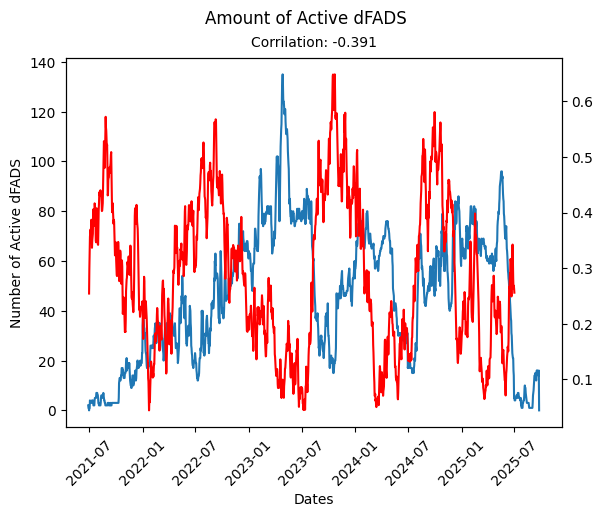

In [24]:
fig, ax = plt.subplots()
ax.plot(daily_changes["Dates"],daily_changes["active_dFADs"])
ax2 = ax.twinx()
#ax2.plot(uo["time"], utimseries, color = "r")
#ax2.plot(vo["time"], vtimseries,color = "g" )
ax2.plot(vo["time"], speedroll, color = "r")
ax2.set_label("Speed of Ocean")
ax.set_ylabel("Number of Active dFADS")
ax.set_xlabel("Dates")
ax.set_xlim()
ax.annotate(f"Corrilation: {corrilation:.3f}", (0.5, 1.03), xycoords="axes fraction", ha="center")
fig.suptitle("Amount of Active dFADS")
ax.tick_params(axis='x', labelrotation=45)
fig.savefig(r"..\Figures\Number of dFADs active.png")

In [15]:
active_dFADS = pd.Series(daily_changes["active_dFADs"])
speed = pd.Series(speed)
corrilation = active_dFADS.corr(speed, method= "pearson")
print(corrilation)

-0.39117346838593714


In [53]:
shift = 20
shiftrange = range(-shift,shift)
corrs = []
for i in shiftrange:
    corrilation = active_dFADS.corr(speed.shift(i), method= "pearson")
    corrs.append(corrilation)

print(corrs)

[np.float64(-0.4709644540654492), np.float64(-0.47180823370642605), np.float64(-0.4735960505930466), np.float64(-0.4757866149608758), np.float64(-0.47687297284961866), np.float64(-0.47626719896566705), np.float64(-0.47458431518400085), np.float64(-0.4737723981496712), np.float64(-0.47272719744924624), np.float64(-0.4691544391170389), np.float64(-0.46660148990122), np.float64(-0.4653988768549737), np.float64(-0.46320305110224513), np.float64(-0.46176819495912624), np.float64(-0.4615041059923483), np.float64(-0.46009261491189746), np.float64(-0.45803824152982997), np.float64(-0.4570063356649145), np.float64(-0.4564854771547149), np.float64(-0.45611831338995656), np.float64(-0.45505095670325024), np.float64(-0.4563308063789596), np.float64(-0.456140938125685), np.float64(-0.4562205929405354), np.float64(-0.45627411166665666), np.float64(-0.4535065127927451), np.float64(-0.45150865921834593), np.float64(-0.4510022043595474), np.float64(-0.44798836374071294), np.float64(-0.44591526887621025